# CSDS 133: Introduction to Data Science
## Homework 6: Machine Learning Algorithms
## Due: Friday, December 5, 11:59PM

### Topics Covered:
- K-Nearest Neighbors (KNN)
- K-Means Clustering
- Linear Regression
- DBSCAN Clustering
- Principal Component Analysis (PCA)

### Instructions:
- Complete all 20 questions below
- Write your code in the designated cells
- Display/print results as requested
- You may use sklearn documentation and class materials
- Submit this notebook when complete

### Setup: Import Required Libraries

In [1]:
# Fix for threadpoolctl issue on some systems
import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_diabetes, make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error, silhouette_score, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Part 1: K-Nearest Neighbors (KNN)
---

### Question 1: Understanding Training vs Test Accuracy

Load the wine dataset and split it into training (70%) and testing (30%) sets.

Train a KNN classifier with k=1 on the training data.

Calculate and print BOTH the training accuracy and test accuracy.

Then repeat with k=10.

**Questions to answer:**
- What do you notice about the difference between training and test accuracy?

In [10]:
# YOUR CODE HERE:
wine_data = load_wine(as_frame=True)

x_train, x_test, y_train, y_test = train_test_split(wine_data.data, wine_data.target, test_size=0.30)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)

print("K = 1")
print("Training Accuracy:", knn.score(x_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, knn.predict(x_test)))

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train, y_train)

print("\nK = 10")
print("Training Accuracy:", knn.score(x_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, knn.predict(x_test)))

# Training accuracy is higher than the test accuracy

K = 1
Training Accuracy: 1.0
Test Accuracy: 0.7962962962962963

K = 10
Training Accuracy: 0.7741935483870968
Test Accuracy: 0.7037037037037037


### Question 2: Effect of K with Cross-Validation

Using the wine dataset, test KNN classifiers with k values from 1 to 30.

For each k, calculate both training and test accuracy.

Create a plot with two lines showing:
- Training accuracy vs k (one line)
- Test accuracy vs k (another line)

Label your axes, include a legend, and add a title.

**Questions to answer:**
- What value of k gives the best test accuracy?
- At what point does increasing k start to hurt performance?

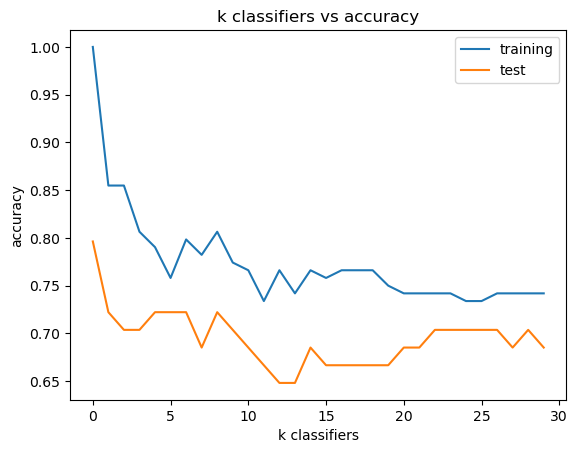

In [11]:
# YOUR CODE HERE:
tracc = []
tsacc = []

for i in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)

    tracc.append(knn.score(x_train, y_train))
    tsacc.append(accuracy_score(y_test, knn.predict(x_test)))

plt.plot(tracc, label="training")
plt.plot(tsacc, label="test")

plt.title("k classifiers vs accuracy")
plt.ylabel("accuracy")
plt.xlabel("k classifiers")
plt.legend()

plt.show()

# The best test accuracy is reached around k=1
# Accuracy shows a general decrease as k increases

### Question 3: Impact of Feature Scaling on KNN

Load the wine dataset and split it 70-30.

Train a KNN classifier (k=5) on the UNSCALED data and record test accuracy.

Then standardize the features using StandardScaler (fit on training data only!).

Train another KNN classifier (k=5) on the SCALED data and record test accuracy.

Print both accuracies.

**Questions to answer:**
- Why does scaling matter for KNN?
- Which performs better?

In [12]:
# YOUR CODE HERE:
x_train, x_test, y_train, y_test = train_test_split(wine_data.data, wine_data.target, test_size=0.30)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

print("Unscaled")
print("Training Accuracy:", knn.score(x_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, knn.predict(x_test)))

scaler = StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
knn.fit(x_train, y_train)

print("\nScaled")
print("Training Accuracy:", knn.score(x_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, knn.predict(x_test)))

# Scaled data normalizes the effect of distance between data points on the final prediction of the model
# The model trained on scaled data performs significantly better

Unscaled
Training Accuracy: 0.7741935483870968
Test Accuracy: 0.7222222222222222

Scaled
Training Accuracy: 0.9838709677419355
Test Accuracy: 0.9814814814814815


### Question 4: Visualizing KNN Decision Boundaries

Load the iris dataset and use only the first 2 features.

Train a KNN classifier with k=7.

Create a visualization showing:
- The decision boundaries (use a meshgrid with step size 0.02)
- The actual data points as a scatter plot
- Different colors for different classes

Use `plt.contourf()` for decision boundaries and `plt.scatter()` for data points.

Add axis labels and a title.

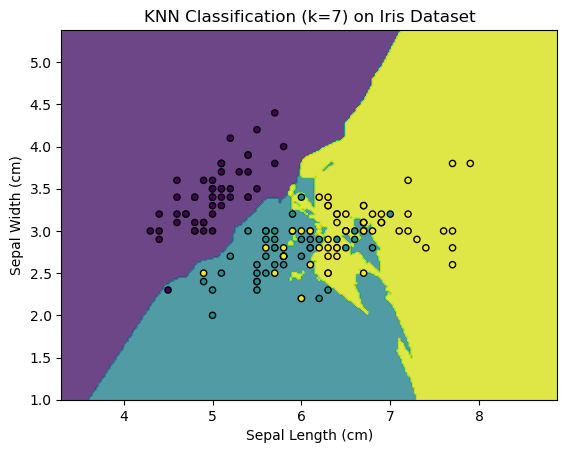

In [13]:
# YOUR CODE HERE:
iris_data = load_iris()
x = iris_data.data[:, :2]
y = iris_data.target

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x, y)

step = .02
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)

plt.scatter(x[:, 0], x[:, 1], c=y, edgecolor='k', s=20)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f"KNN Classification (k={7}) on Iris Dataset")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()

---
# Part 2: K-Means Clustering
---

### Question 5: Basic K-Means Clustering

Create a synthetic dataset using `make_blobs` with:
- n_samples=300
- centers=4
- cluster_std=0.6
- random_state=0

Apply K-Means clustering with k=4.

Print the cluster centers and create a scatter plot showing:
- Data points colored by their cluster assignment
- Cluster centers marked with a different symbol (e.g., red 'X')

Centers:
 [[-1.37324398  7.75368871]
 [-1.58438467  2.83081263]
 [ 1.98258281  0.86771314]
 [ 0.94973532  4.41906906]]


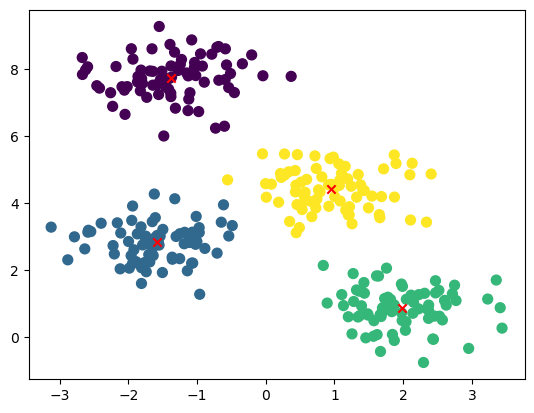

In [14]:
# YOUR CODE HERE:
x, y = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)

km = KMeans(n_clusters=4)
km.fit(x)

centers = km.cluster_centers_
print("Centers:\n", centers)

y_kmeans = km.predict(x)
plt.scatter(x[:, 0], x[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker="x")

### Question 6: Finding Optimal K using Elbow Method

Using the same synthetic dataset from Q5, test k values from 2 to 10.

For each k, calculate the inertia (sum of squared distances to nearest cluster center).

Plot the elbow curve (k vs inertia).

**Question to answer:** Based on the plot, what is the optimal number of clusters?

Text(0, 0.5, 'inertia')

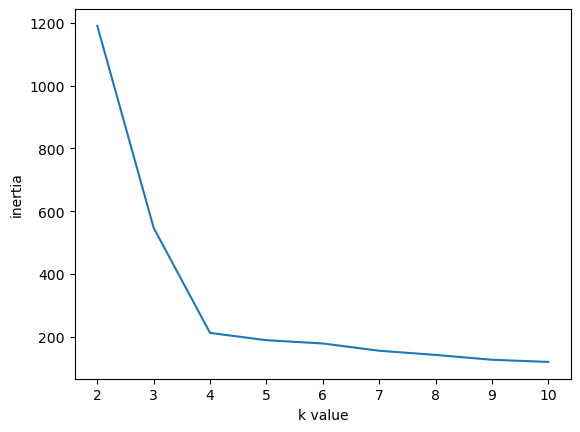

In [15]:
# YOUR CODE HERE:
inertias = []

for i in range(2, 11):
    km = KMeans(n_clusters=i)
    km.fit(x)

    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias)
plt.xlabel("k value")
plt.ylabel("inertia")

# Based on the plot, the optimal number of clusters is 4

### Question 7: K-Means on Real Data

Load the iris dataset (use all 4 features).

Apply K-Means with k=3 (since there are 3 iris species).

Calculate and print the silhouette score.

Create a 2D visualization by plotting only the first two features, colored by cluster assignment.

**Note:** This is unsupervised, so clusters may not match the true species labels.

Silhouette Score: 0.551191604619592


Text(0, 0.5, 'Sepal Width (cm)')

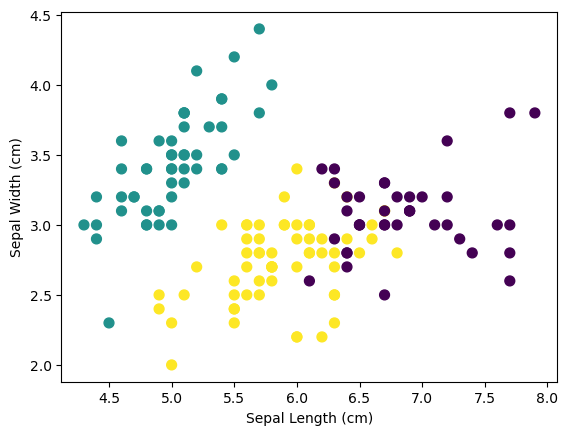

In [16]:
# YOUR CODE HERE:
iris = load_iris()
data = iris.data
target = iris.target

km = KMeans(n_clusters=3)
predicted = km.fit_predict(data)

print("Silhouette Score:", silhouette_score(data, predicted))

plt.scatter(data[:, 0], data[:, 1], c=predicted, s=50, cmap='viridis')
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

### Question 8: Comparing Cluster Assignments

Using the iris dataset and K-Means with k=3 from Q7:

Create a confusion-like comparison showing how many samples from each true species (0, 1, 2) ended up in each cluster (0, 1, 2).

**Hint:** You can use a nested loop or numpy's unique function with counts.

Print the result as a 3x3 matrix.

Text(0, 0.5, 'Actual Species')

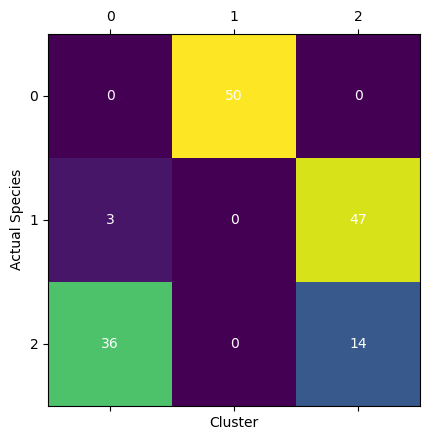

In [17]:
# YOUR CODE HERE:
matrix = [[0, 0, 0],
          [0, 0, 0], 
          [0, 0, 0]]

for i in range(0, len(target)):
    matrix[target[i]][predicted[i]] += 1

plt.matshow(matrix)

for r in range(0, len(matrix)):
    for c in range(0, len(matrix[r])):
        plt.text(c, r, str(matrix[r][c]), ha='center', va='center', color='white')

plt.xlabel("Cluster")
plt.ylabel("Actual Species")

---
# Part 3: Linear Regression
---

### Question 9: Simple Linear Regression

Load the diabetes dataset and use only the 'bmi' feature (index 2).

Split into 80-20 train-test sets.

Train a Linear Regression model.

Print the coefficient and intercept.

Calculate and print the Mean Squared Error (MSE) on the test set.

In [18]:
# YOUR CODE HERE:
diabetes = load_diabetes()
x_train, x_test, y_train, y_test = train_test_split(diabetes.data[:, np.newaxis, 2], diabetes.target, test_size=0.20)

lr = LinearRegression()
lr.fit(x_train, y_train)

print("Coefficient:", lr.coef_[0])
print("Intercept:", lr.intercept_)

Coefficient: 894.8783727788543
Intercept: 150.9879804581504


### Question 10: Visualizing Linear Regression

Using the same setup as Q9 (diabetes dataset, BMI feature):

Create a scatter plot of the test data (BMI vs target).

Plot the regression line on the same figure.

Add axis labels, title, and legend.

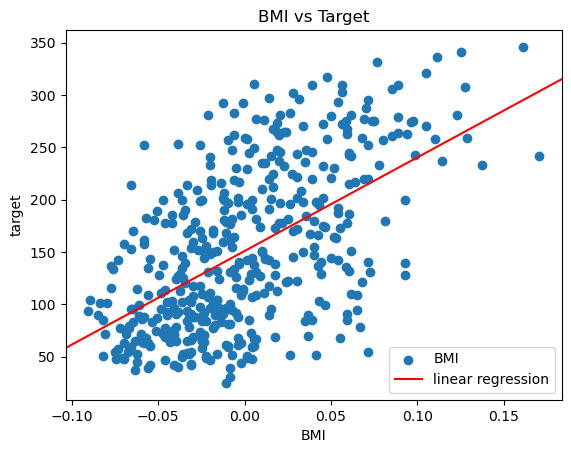

In [19]:
# YOUR CODE HERE:
plt.scatter(diabetes.data[:, 2], diabetes.target, label="BMI")
plt.axline((0, lr.intercept_), slope=lr.coef_[0], c="red", label="linear regression")

plt.xlabel("BMI")
plt.ylabel("target")
plt.title("BMI vs Target")
plt.legend(loc='lower right')

### Question 11: Multiple Linear Regression

Load the diabetes dataset and use ALL features.

Split into 80-20 train-test sets.

Train a Linear Regression model.

Print the MSE on both training and test sets.

Print the R² score on the test set.

**Question to answer:** Is there evidence of overfitting or underfitting?

In [20]:
# YOUR CODE HERE:
x_train, x_test, y_train, t_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2)

lr = LinearRegression()
lr.fit(x_train, y_train)

print("MSE training set:", mean_squared_error(y_train, lr.predict(x_train)))
print("MSE test set:", mean_squared_error(y_test, lr.predict(x_test)))
print("R2 test set:", r2_score(y_test, lr.predict(x_test)))

# As the model is not performing significantly worse on the test set, it is reasonable to conclude that there is not evidence of overfitting or underfitting

MSE training set: 2818.8033903193264
MSE test set: 11809.50244933048
R2 test set: -0.7038922095144293


### Question 12: Feature Importance in Linear Regression

Using the model from Q11:

Print all feature coefficients along with feature names.

Create a horizontal bar plot showing the absolute values of coefficients.

**Hint:** `diabetes.feature_names` contains the feature names.

**Question to answer:** Which feature has the strongest effect on the target variable?

age : -26.05069315782192
sex : -271.44164309014127
bmi : 570.2943583549651
bp : 302.2462225365836
s1 : -624.7717983528361
s2 : 335.53518144683255
s3 : 56.25826322572231
s4 : 158.6634783788761
s5 : 739.0276928888334
s6 : 85.60262109994476


Text(0, 0.5, 'Features')

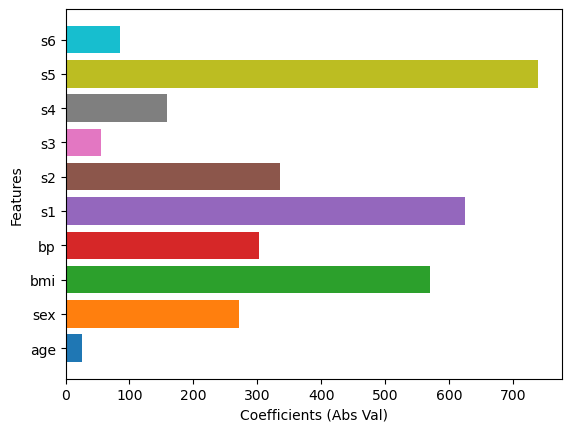

In [21]:
# YOUR CODE HERE:
for i in range(0, len(diabetes.feature_names)):
    feature = diabetes.feature_names[i]
    coef = lr.coef_[i]
    
    print(feature, ":", coef)
    plt.barh(feature, abs(coef))

plt.xlabel("Coefficients (Abs Val)")
plt.ylabel("Features")

# s1 has the largest coefficient, and therefore the largest effect on the target variable

---
# Part 4: DBSCAN Clustering
---

### Question 13: Basic DBSCAN

Create a synthetic dataset using `make_moons` with:
- n_samples=200
- noise=0.05
- random_state=0

Apply DBSCAN with eps=0.3 and min_samples=5.

Print the number of clusters found (excluding noise points).

Print the number of noise points (labeled as -1).

In [22]:
# YOUR CODE HERE:
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X)

clusters = []
noise_count = 0
for l in dbscan.labels_:
    if l == -1:
        noise_count += 1
        continue

    if l not in clusters:
        clusters.append(l)

print("Clusters found:", len(clusters))
print("Noise points found:", noise_count)

Clusters found: 2
Noise points found: 0


### Question 14: Visualizing DBSCAN Results

Using the same dataset and DBSCAN model from Q13:

Create a scatter plot where:
- Each cluster has a different color
- Noise points are shown in black

Add a title and axis labels.

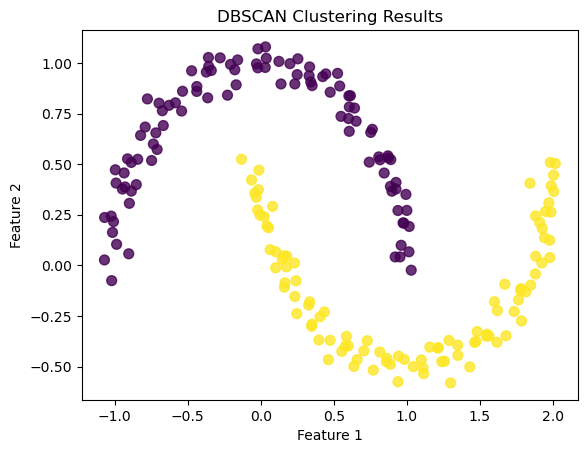

In [23]:
# YOUR CODE HERE:
clusters = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.8)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Question 15: Effect of Epsilon on DBSCAN

Using `make_blobs` to create a dataset with:
- n_samples=300
- centers=3
- cluster_std=0.5
- random_state=0

Test DBSCAN with min_samples=5 and eps values: [0.1, 0.3, 0.5, 0.7, 1.0]

For each eps value, print:
- The eps value
- Number of clusters found
- Number of noise points

In [24]:
# YOUR CODE HERE:
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=0)

eps_values = [0.1, 0.3, 0.5, 0.7, 1.0]
for e in eps_values:
    dbscan = DBSCAN(eps=e, min_samples=5)
    dbscan.fit(X)

    noise_count = 0
    clusters = []
    for l in dbscan.labels_:
        if l == -1:
            noise_count += 1
            continue

        if l not in clusters:
            clusters.append(l)

    print("Epsilon:", e)
    print("Clusters found:", len(clusters))
    print("Noise points found:", noise_count, "\n")

Epsilon: 0.1
Clusters found: 4
Noise points found: 278 

Epsilon: 0.3
Clusters found: 4
Noise points found: 38 

Epsilon: 0.5
Clusters found: 3
Noise points found: 4 

Epsilon: 0.7
Clusters found: 3
Noise points found: 0 

Epsilon: 1.0
Clusters found: 2
Noise points found: 0 



### Question 16: DBSCAN vs K-Means

Create a dataset with `make_moons`:
- n_samples=300
- noise=0.1
- random_state=0

Apply both:
- K-Means with k=2
- DBSCAN with eps=0.3 and min_samples=5

Create a side-by-side subplot (1 row, 2 columns) comparing the clustering results.

Title each subplot appropriately.

**Question to answer:** Which algorithm works better for this non-linear dataset?

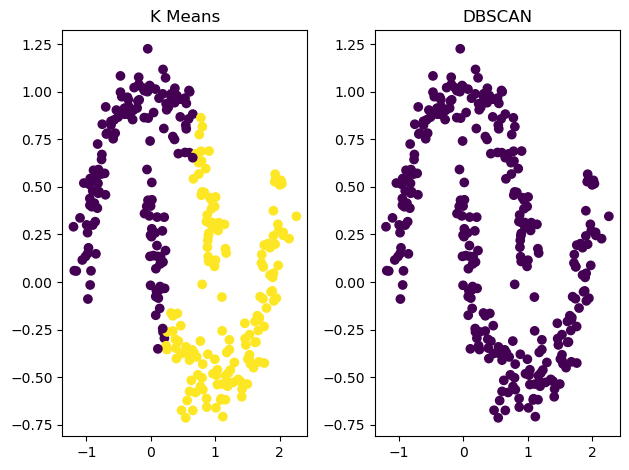

In [25]:
# YOUR CODE HERE:
X, y = make_moons(n_samples=300, noise=0.1, random_state=0)

km = KMeans(n_clusters=2)
km_predicted = km.fit_predict(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
db_predicted = dbscan.fit_predict(X)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.scatter(X[:, 0], X[:, 1], c=km_predicted)
ax1.set_title("K Means")

ax2.scatter(X[:, 0], X[:, 1], c=db_predicted)
ax2.set_title("DBSCAN")

plt.tight_layout()

# With these parameters for dataset generation, k means actually performs better by identifying more than one group

---
# Part 5: Principal Component Analysis (PCA)
---

### Question 17: Basic PCA

Load the iris dataset (all 4 features).

Standardize the features using StandardScaler.

Apply PCA to reduce to 2 components.

Print the explained variance ratio for each component.

**Question to answer:** What percentage of total variance is explained by these 2 components?

In [26]:
# YOUR CODE HERE:
iris = load_iris()

scaler = StandardScaler()
data = scaler.fit_transform(iris.data)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

print("Component 1 variance ratio:", pca.explained_variance_ratio_[0])
print("Component 2 variance ratio:", pca.explained_variance_ratio_[1])

# ~96% of the variance is explained by these two components

Component 1 variance ratio: 0.7296244541329991
Component 2 variance ratio: 0.22850761786701745


### Question 18: Visualizing PCA Results

Using the PCA transformation from Q17:

Create a scatter plot of the data in the 2D PCA space.

Color the points by their true species label.

Add axis labels (PC1, PC2), title, and legend.

**Question to answer:** Are the species well-separated in this reduced space?

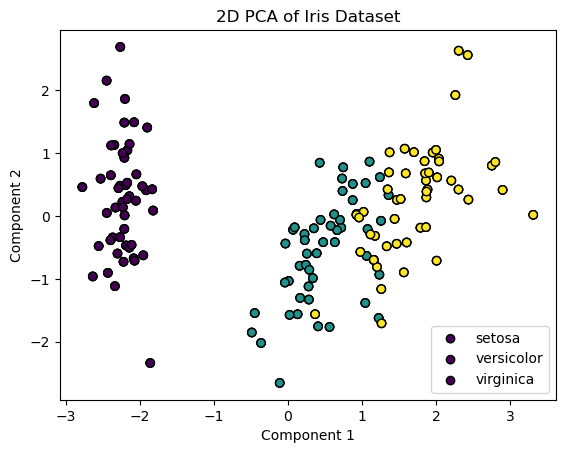

In [27]:
# YOUR CODE HERE:
for name in iris.target_names:
    plt.scatter(principal_components[:, 0], principal_components[:, 1], c=iris.target, edgecolors='k', label=name)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("2D PCA of Iris Dataset")
plt.legend()

# The Setosa species is distinctly seperated, but the veriscolor and virginica species have a significant overlap

### Question 19: Choosing Number of Components

Load the wine dataset and standardize the features.

Apply PCA without specifying n_components (uses all components).

Create a plot showing:
- Cumulative explained variance vs number of components
- A horizontal line at 95% variance

**Question to answer:** How many components are needed to explain at least 95% of the variance?

Text(0, 0.5, 'Cumulative Explained Variance')

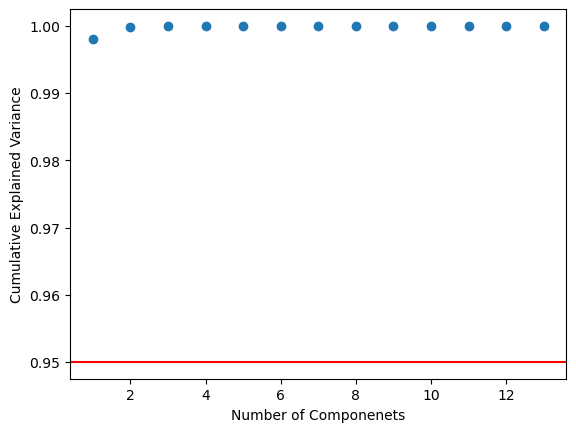

In [28]:
# YOUR CODE HERE:
wine = load_wine()

pca = PCA()
pca.fit(wine.data)

cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.scatter(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance)
plt.axhline(y=0.95, color='red')

plt.xlabel("Number of Componenets")
plt.ylabel("Cumulative Explained Variance")

# 95% of variance is explained for every number of componenets

### Question 20: PCA for Visualization and Classification

Load the wine dataset and standardize the features.

Apply PCA to reduce to 2 components.

Split the transformed data into 80-20 train-test sets.

Train a KNN classifier (k=5) on the PCA-transformed data.

Print the accuracy on the test set.

Compare this to training KNN on the original 13 features (also print that accuracy).

**Question to answer:** Does PCA improve or hurt classification performance?

In [30]:
# YOUR CODE HERE:
wine = load_wine()

data = StandardScaler().fit_transform(wine.data)

pca = PCA(n_components=2)
data = pca.fit_transform(data)

x_train, x_test, y_train, y_test = train_test_split(data, wine.target, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

print("PCA-Transformed KNN Test Accuracy:", accuracy_score(y_test, knn.predict(x_test)))


x_train, x_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

print("Non-Transformed KNN Test Accuracy:", accuracy_score(y_test, knn.predict(x_test)))

# Using PCA to transform data shows a signifcant improvement in KNN model performance

PCA-Transformed KNN Test Accuracy: 0.9444444444444444
Non-Transformed KNN Test Accuracy: 0.6944444444444444


---
# Submission
---

Make sure all questions are answered and all requested outputs are displayed.

Before submitting:
1. Restart the kernel and run all cells
2. Verify that all outputs are visible
3. Check that all questions have been answered
4. Make sure you've explained your result if the question asked for it.